[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 07 Filtering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.tsa.stattools as stattools

## Trend

In [2]:
df = pd.read_csv("./NASA_GISTEMP.csv", parse_dates=["date"])
df

,Unnamed: 0,Year,Month,Anomaly,date
0,0,1990,1,0.42,1990-01-01
1,1,1990,2,0.44,1990-02-01
2,2,1990,3,0.80,1990-03-01
3,3,1990,4,0.56,1990-04-01
4,4,1990,5,0.46,1990-05-01
...,...,...,...,...,...
427,427,2025,8,1.18,2025-08-01
428,428,2025,9,1.25,2025-09-01
429,429,2025,10,1.19,2025-10-01
430,430,2025,11,1.21,2025-11-01


Text(0.5, 1.0, 'NASA GSTEMP')

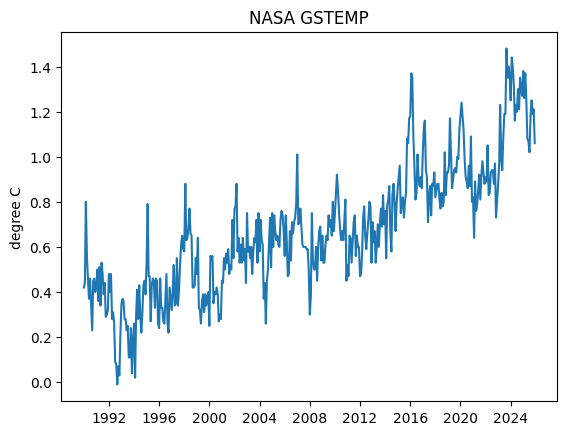

In [3]:
plt.plot(df.date, df.Anomaly)
plt.ylabel('degree C')
plt.title('NASA GSTEMP')

- trend: here we are using Numpy's polynomial fit (1st order)

(One can use statsmodels's Ordinary Linear Square Regression, which we will practice in the next lecture)

- let's get x (anomaly), length (n), and index (t)

In [4]:
anomaly = df["Anomaly"].values
n = len(anomaly)
t = np.arange(n) ## df.index.values



-  polynomial fit

In [5]:
slope, intercept = np.polyfit(t, anomaly, 1)

- trend & residual


In [6]:
trend = intercept+slope*t ## np.poly1d((slope, intercept))(t)

In [7]:
resid = anomaly - trend

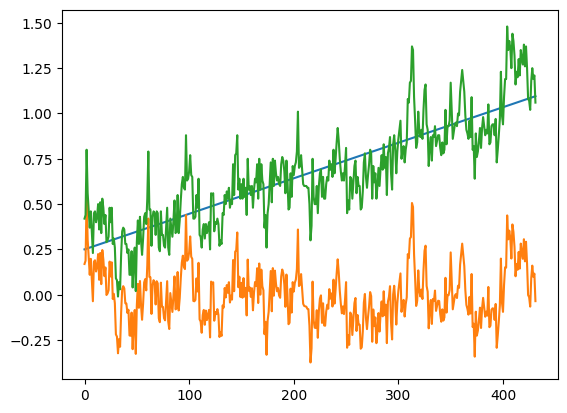

In [8]:
plt.plot(t, trend)
plt.plot(t,resid)
plt.plot(t,trend+resid)

- report the warming rate: slope

In [9]:
slope
print('slope', slope, 'unit? per month?')

slope 0.0019608046703782495 unit? per month?


In [10]:
# Convert slope to per-year (since x_idx is in months)
slope_per_year = slope * 12

print(f"Warming trend: {slope_per_year:.4f} °C/year")


Warming trend: 0.0235 °C/year


- Confidence interval with $\alpha = 0.05$.

$CI = t_{crtical}\times SE(\hat{b})$

$SE(\hat{b}) = \frac{\hat{\sigma}_\varepsilon}{\sqrt{\sum_{t}(t-\bar{t})^2}}$

$= \frac{\sqrt{\sum_{t}\hat{\varepsilon}_t^{\,2}/(n-2)}}{\sqrt{\sum_{t}(t-\bar{t})^2}}$

In [11]:
sigma_hat = np.sqrt(np.sum(resid**2)/(n-2))
sigma_hat

np.float64(0.15353358495013247)

In [12]:
sqrt_ss_t = np.sqrt(np.sum((t - t.mean())**2))

In [13]:
SE_b_hat =sigma_hat/sqrt_ss_t
SE_b_hat

np.float64(5.9233794867469595e-05)

In [14]:
alpha = 0.05
t_critical_naive=stats.t.ppf(1-alpha/2, n-2)
print('t-stat with n:', t_critical_naive)
print(f"95% CI with n: {t_critical_naive*SE_b_hat*12:4f} °C/year")

t-stat with n: 1.9654961915712994
95% CI with n: 0.001397 °C/year


- check autocorrelation and derive effective N if necessary

In [15]:
rho1   = stattools.acf(resid, nlags=1, adjusted=False)[1]
n_eff = n * (1 - rho1) / (1 + rho1)
CI_acf = 1.96/np.sqrt(n)
print(f"rho: {rho1},CI_acf: {CI_acf} ")


rho: 0.669826360977716,CI_acf: 0.09430054396763887 


- cacluate effective SE

In [16]:
SE_b_hat_Neff = SE_b_hat*np.sqrt(n/n_eff)
SE_b_hat_Neff

np.float64(0.0001332091371618354)

In [17]:
t_critical_Neff=stats.t.ppf(1-alpha/2, n_eff-2)
print('t-crit with n:', t_critical_Neff)
print(f"95% CI with n: +/-{t_critical_Neff*SE_b_hat_Neff*12:4f} °C/year")

t-crit with n: 1.9888120224144088
95% CI with n: +/-0.003179 °C/year


In [18]:
ci = t_critical_Neff*SE_b_hat_Neff
print(f"warming rate range 95%CI: [{slope_per_year-ci*12:.4f} , {slope_per_year+ci*12:4f}] oC/year")

warming rate range 95%CI: [0.0204 , 0.026709] oC/year


In [19]:

trend_top = trend + ci*t.max()
trend_bottom = trend - ci*t.max()

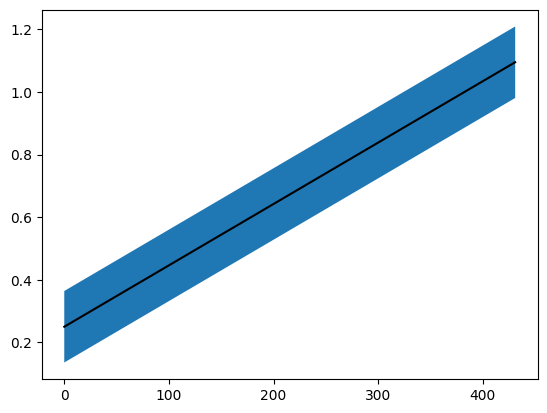

In [20]:
plt.plot(t, trend,'k')
plt.fill_between(t,trend_top, trend_bottom)


-- back to lecture --

-- hands on --

- load data, organize the data and convert Fahrenheit to Celsius

In [22]:
df = pd.read_csv("./NYC_data.csv", parse_dates=["DATE"])
df = df.dropna(subset=["TMAX"]).sort_values("DATE").reset_index(drop=True)
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month
df["TMAX_C"] = (df["TMAX"] - 32) * 5/9   # Fahrenheit -> Celsius
df

,STATION,NAME,DATE,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,WT06,WT08,WT09,Year,Month,TMAX_C
0,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-01,0.00,0.0,NaN,20.0,28,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,-2.222222
1,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-02,0.00,0.0,NaN,17.0,25,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,-3.888889
2,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-03,2.42,0.0,NaN,38.0,51,24,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1999,1,10.555556
3,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-04,0.00,0.0,NaN,26.0,32,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,0.000000
4,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-05,0.00,0.0,NaN,23.0,28,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,-2.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10073,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-07-31,0.03,0.0,0.0,NaN,85,67,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2026,7,29.444444
10074,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-01,0.00,0.0,0.0,NaN,86,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,8,30.000000
10075,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-02,0.07,0.0,0.0,NaN,83,75,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2026,8,28.333333
10076,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-03,1.93,0.0,0.0,NaN,80,71,1.0,NaN,1.0,NaN,NaN,NaN,NaN,2026,8,26.666667


In [23]:
## July
month = 7
sub = df[df["Month"] == month]
counts = sub.groupby("Year")["TMAX_C"].count()
yearly = sub.groupby("Year")["TMAX_C"].mean().reset_index()
yearly = yearly[yearly["Year"].isin(counts[counts >= 20].index)].reset_index(drop=True)
yearly

,Year,TMAX_C
0,1999,32.275986
1,2000,26.093190
2,2001,27.240143
3,2002,30.537634
4,2003,28.351254
5,2004,27.168459
6,2005,29.372760
7,2006,29.534050
8,2007,27.956989
9,2008,30.125448


### Seasonality

- borrow the code abvoe for calculate July mean TMAx_c each year, and loop it over to get monthly climatology

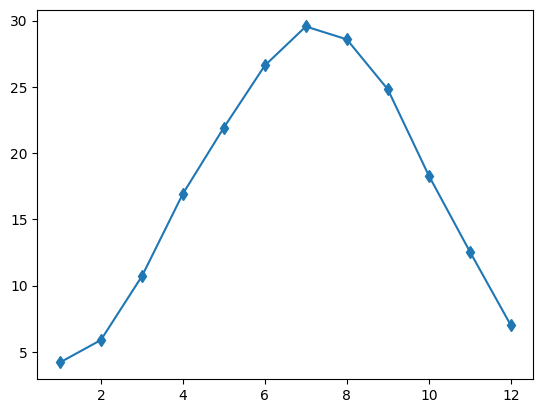

In [24]:
month_label = np.arange(1,13)
monthly = np.zeros(12)
anom_list = []
for imonth in month_label:
    sub = df[df["Month"] == imonth]
    counts = sub.groupby("Year")["TMAX_C"].count()
    yearly = sub.groupby("Year")["TMAX_C"].mean().reset_index()
    yearly = yearly[yearly["Year"].isin(counts[counts >= 20].index)].reset_index(drop=True)
    monthly[imonth-1] = yearly["TMAX_C"].mean()

plt.plot(month_label, monthly,'d-')

In [25]:
#
#    yearly["Month"] = imonth
#    yearly["anom"] = yearly["TMAX_C"] - monthly[imonth-1]
#    anom_list.append(yearly)
#anom = pd.concat(anom_list).sort_values(["Year", "Month"]).reset_index(drop=True)

- OR more advanced, useing groupby and agg function in pandas

In [26]:
g = df.groupby(["Year", "Month"])["TMAX_C"]
monthly = g.mean()[g.count() >= 20].reset_index()    # complete months only
clim = monthly.groupby("Month")["TMAX_C"].agg(["mean", "std", "count"])

- calculate anomaly by mapping the climatology back to the time series and then subtracting form the raw data

In [27]:
monthly["anom"] = monthly["TMAX_C"] - monthly["Month"].map(clim["mean"])
monthly

,Year,Month,TMAX_C,anom
0,1999,1,4.892473,0.704045
1,1999,2,7.361111,1.478126
2,1999,3,10.358423,-0.336022
3,1999,4,16.851852,-0.072090
4,1999,5,21.702509,-0.219534
...,...,...,...,...
326,2026,3,12.831541,2.137097
327,2026,4,17.981481,1.057540
328,2026,5,21.971326,0.049283
329,2026,6,27.462963,0.850529


<Axes: >

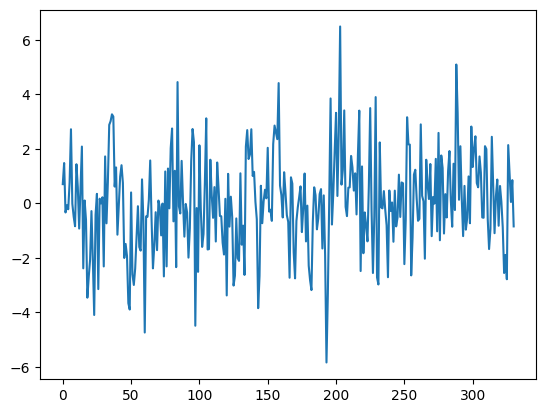

In [28]:
monthly["anom"].plot()

### running mean

1. running trend

In [29]:
monthly

,Year,Month,TMAX_C,anom
0,1999,1,4.892473,0.704045
1,1999,2,7.361111,1.478126
2,1999,3,10.358423,-0.336022
3,1999,4,16.851852,-0.072090
4,1999,5,21.702509,-0.219534
...,...,...,...,...
326,2026,3,12.831541,2.137097
327,2026,4,17.981481,1.057540
328,2026,5,21.971326,0.049283
329,2026,6,27.462963,0.850529


$$
\bar{x}_i = \frac{1}{N}\left[\frac{1}{2}x_{i-h} + \sum_{k=-h+1}^{h-1} x_{i+k} + \frac{1}{2}x_{i+h}\right],
\qquad h = \left\lfloor \frac{N}{2} \right\rfloor,\quad h \le i \le n-h-1
$$


$$
\bar{x}_i = \frac{1}{N}\left[\sum_{k=-h}^{h} x_{i+k} \right],
\qquad h = \left\lfloor \frac{N-1}{2} \right\rfloor,\quad h \le i \le n-h-1
$$

where $N$ is `t_step`, $h$ is `t_d2`, and $n$ is the length of $x$.

OR:

$$
\bar{x}_i = \sum_{k=-h}^{h} w_k\, x_{i+k},
\qquad h = \left\lfloor \frac{K}{2} \right\rfloor,\quad h \le i \le n-h-1
$$

$$
w_k =
\begin{cases}
\dfrac{1}{K}, & |k| < h \\[6pt]
\dfrac{1}{K}, & |k| = h \text{ and } K \text{ odd} \\[6pt]
\dfrac{1}{2K}, & |k| = h \text{ and } K \text{ even}
\end{cases}
$$

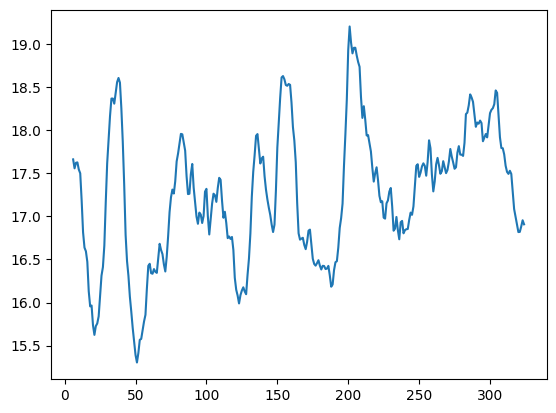

In [30]:
x = monthly["TMAX_C"].values
t_step = 12
n = len(x); out = np.full(n, np.nan)

## running mean for both even or odd number t_step
h = t_step // 2
for i in range(h, n - h):
    w = x[i-h:i+h+1].copy()
    if t_step % 2 == 0:
        w[0] *= 0.5; w[-1] *= 0.5
    out[i] = w.sum() / t_step
running_trend = pd.Series(out, index=monthly.index)
plt.plot(running_trend)
monthly['running_trend'] = running_trend


2. get de-trend monthly mean

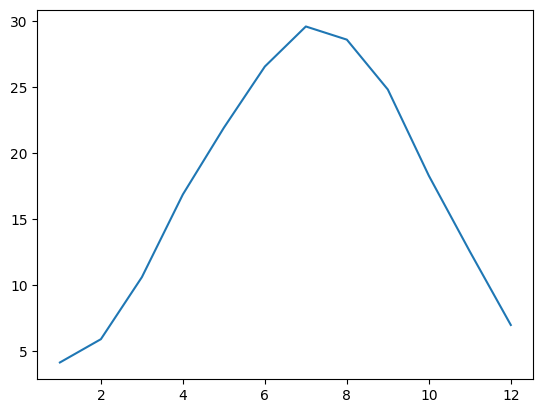

In [31]:
running_seasonal = (monthly["TMAX_C"] - running_trend).groupby(monthly["Month"]).mean()
#running_seasonal -= running_seasonal.mean()      # seasonal cycle sums to zero
plt.plot(running_seasonal+running_trend.mean())


3. get residual

(150.0, 250.0)

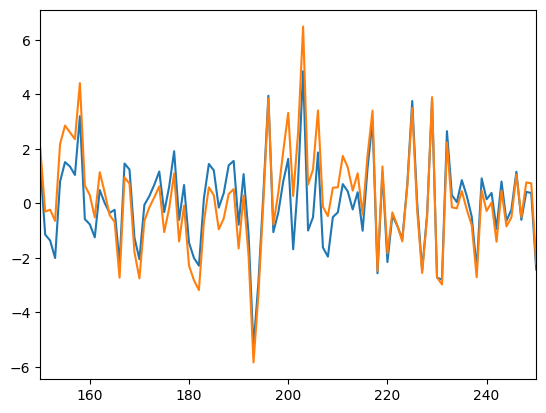

In [32]:
seasonal_full = monthly["Month"].map(running_seasonal)
monthly['running_anomaly'] = monthly["TMAX_C"] - running_trend - seasonal_full
plt.plot(monthly['running_anomaly'])
plt.plot(monthly['anom'])
plt.xlim([150,250])

-- hands on --

In [34]:
d = pd.read_csv("PRISM_ppt_tmean_45.0000_-123.0000_189501_202607.csv")
d["Date"] = pd.to_datetime(d["Date"], format="%Y-%m")
d["Year"], d["Month"] = d.Date.dt.year, d.Date.dt.month
d["time"] = d.Year + (d.Month - 0.5) / 12
d["T"] = (d["tmean (degrees F)"] - 32) * 5 / 9                 # degC



In [35]:
# (1) climatology -> seasonality, and deseasonalized anomaly
clim = d.groupby("Month")["T"].mean()
d["anom"] = d["T"] - d["Month"].map(clim)

In [36]:
# (2) linear trend of deseasonalized monthly anomalies
t = d["time"].values; y = d["anom"].values; n = len(y)
b, a = np.polyfit(t, y, 1)
e = y - (a + b*t); S = np.sum((t - t.mean())**2)
se_naive = np.sqrt(np.sum(e**2) / (n - 2) / S)
r1 = stattools.acf(e, nlags=1, adjusted=False)[1]
neff = n * (1 - r1) / (1 + r1)
CI_95_r1 = 1.96/np.sqrt(n)
print(r1, CI_95_r1)

0.20247852462929927 0.04932476290457103


In [37]:
se_eff =  se_naive*np.sqrt(n/neff)
p_eff = 2 * stats.t.sf(abs(b / se_eff), neff - 2)
ci = stats.t.ppf(0.975, neff - 2) * se_eff
print(f"(2) anomaly trend: {b*100:+.3f} C/century, 95%CI ±{ci*100:.3f}, p={p_eff:.2g}")

(2) anomaly trend: +0.633 C/century, 95%CI ±0.215, p=1.1e-08


In [38]:
def running_mean_centered(x,t_step):
    out = np.full(len(x), np.nan)
    h = t_step // 2
    for i in range(h, n - h):
        w = x[i-h:i+h+1].copy()
        if t_step % 2 == 0:
            w[0] *= 0.5; w[-1] *= 0.5
        out[i] = w.sum() / t_step
    return out

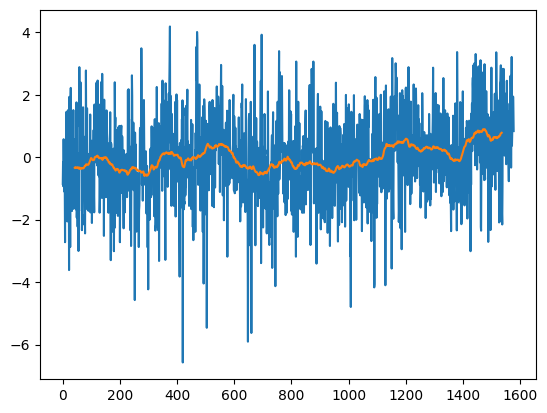

In [39]:
y_7yr = running_mean_centered(y,7*12)
plt.plot(y)
plt.plot(y_7yr)


In [40]:
arg_7yr = np.argwhere(y_7yr==y_7yr).ravel()

In [41]:
# (3) linear trend of 7_yr lowpass filter
t = d["time"].values[arg_7yr]; y_prim = y_7yr[arg_7yr]; n = len(y_prim )
b, a = np.polyfit(t, y_prim , 1)
e = y_prim  - (a + b*t); S = np.sum((t - t.mean())**2)
se_naive = np.sqrt(np.sum(e**2) / (n - 2) / S)
r1 = stattools.acf(e, nlags=1, adjusted=False)[1]
neff = n * (1 - r1) / (1 + r1)
CI_95_r1 = 1.96/np.sqrt(n)
print(r1, CI_95_r1)

0.9973958942658325 0.05069153881096343


In [42]:
se_eff =  se_naive*np.sqrt(n/neff)
p_eff = 2 * stats.t.sf(abs(b / se_eff), neff - 2)
ci = stats.t.ppf(0.975, neff - 2) * se_eff
print(f"(2) anomaly trend: {b*100:+.3f} C/century, 95%CI ±{ci*100:.3f}, p={p_eff:.2g}")

(2) anomaly trend: +0.559 C/century, 95%CI ±nan, p=nan
